In [1]:
# =========================
# Standard library imports
# =========================
import sys
import os
import io
import gzip
from pathlib import Path
import math
import json
import pickle
import logging
import random
import subprocess
import warnings
import collections
import itertools
import re
from IPython.display import display

warnings.filterwarnings("ignore")


# =========================
# Numeric / stats
# =========================
import numpy as np
import pandas as pd
from scipy import sparse
from scipy import stats
from scipy.stats import rankdata
from scipy import __version__ as scipy_version


# =========================
# Plotting / visualization
# =========================
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FormatStrFormatter, MaxNLocator
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import seaborn as sns


# =========================
# scikit-learn
# =========================
from sklearn import model_selection, metrics
from sklearn.model_selection import (
    train_test_split,
    GroupShuffleSplit,
    KFold,
    GroupKFold,
    cross_val_score,
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import LocalOutlierFactor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
)
from sklearn import __version__ as sklearn_version


# =========================
# Optimization / AutoML
# =========================
import optuna


# =========================
# LightGBM
# =========================
try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
    _HAS_LGBM = True
except Exception as e:
    _HAS_LGBM = False
    raise RuntimeError(
        "LightGBM not installed. Please install it with `pip install lightgbm`."
    ) from e


# =========================
# RNA structure (ViennaRNA)
# =========================
import RNA


# =========================
# UpSet plots
# =========================
try:
    from upsetplot import UpSet, from_memberships
except Exception:
    _ = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "upsetplot"],
        check=False,
    )
    from upsetplot import UpSet, from_memberships


# =========================
# Model explanation
# =========================
import shap


# =========================
# User-provided utilities
# =========================
import sylib  


# =========================
# Version info
# =========================
print(f"python    = {sys.version_info[0]}.{sys.version_info[1]}.{sys.version_info[2]}")
print(f"pandas    = {pd.__version__}")
print(f"numpy     = {np.__version__}")
print(f"scipy     = {scipy_version}")
print(f"optuna    = {optuna.__version__}")
print(f"sklearn   = {sklearn_version}")
print(f"ViennaRNA = {RNA.__version__}")
print(f"lightgbm  = {lgb.__version__}")
print(f"sylib     = {sylib.__version__}")


# =========================
# Progress bar & logging
# =========================
# progress bar from sylib
progress_bar = sylib.utils.ProgressBar()

# reset handlers then configure logging
logging.root.handlers = []
stream_handler = logging.StreamHandler(sys.stderr)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)8s: %(message)s",
    handlers=[stream_handler],
)
logger = logging.getLogger(__name__)

# make matplotlib quieter
logging.getLogger("matplotlib").setLevel(logging.WARNING)

python    = 3.11.15
pandas    = 2.3.3
numpy     = 2.4.6
scipy     = 1.17.1
optuna    = 4.9.0
sklearn   = 1.9.0
ViennaRNA = 2.7.2
lightgbm  = 4.6.0
sylib     = 0.3.0.dev0+ae18bb2


In [2]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 6.0,
    "dpi": 300,
}


SPECIES_INFO = {
    "AT21": {
        "label": "AT",
        "short": "AT21",
        "color": "#664D0AFF",
        "marker": "o",
    },
    "NB21": {
        "label": "NB",
        "short": "NB21",
        "color": "#7e3131",
        "marker": "^",
    },
    "OS21": {
        "label": "OS",
        "short": "OS21",
        "color": "#13563f",
        "marker": "s",
    },
}

def set_plot_style(
    *,
    base_fontsize=10,
    title_fontsize=12,
    label_fontsize=10,
    tick_fontsize=9,
    legend_fontsize=10,
    dpi=300,
    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,
    tick_size_major=6,
    tick_dir="out",
    grid=False,
    fig_w=6.0,
    fig_h=6.0,
):
    sns.set_style("ticks")

    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,

        "axes.titlesize": title_fontsize,
        "axes.labelsize": label_fontsize,

        "xtick.labelsize": tick_fontsize,
        "ytick.labelsize": tick_fontsize,

        "legend.fontsize": legend_fontsize,

        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        "legend.frameon": False,

        "savefig.bbox": "tight",
        "savefig.transparent": False,
        "figure.autolayout": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(w=None, h=None, dpi=None):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


def _compact_formatter():
    def _fmt(x, _pos=None):
        axx = abs(x)

        if axx >= 1e9:
            s = f"{x / 1e9:.1f}B"
        elif axx >= 1e6:
            s = f"{x / 1e6:.1f}M"
        elif axx >= 1e3:
            s = f"{x / 1e3:.1f}k"
        else:
            s = f"{x:.2g}"

        return (
            s.replace(".0B", "B")
             .replace(".0M", "M")
             .replace(".0k", "k")
        )

    return FuncFormatter(_fmt)


def format_axis(
    ax,
    *,
    xlabel=None,
    ylabel=None,
    compact_ticks=(),
):
    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    fmt = _compact_formatter()

    if "x" in compact_ticks:
        ax.xaxis.set_major_formatter(fmt)

    if "y" in compact_ticks:
        ax.yaxis.set_major_formatter(fmt)

    return ax


# ============================================
# Joint scatter with KDE marginals
# ============================================

def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.pearsonr(x, y)


def safe_spearmanr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.spearmanr(x, y)

def _kde_1d(values, lo, hi, num=256):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    grid = np.linspace(lo, hi, num)

    if len(values) < 2:
        return grid, np.zeros_like(grid)

    try:
        kde = stats.gaussian_kde(values)
        dens = kde(grid)
        dens /= dens.max() if dens.max() > 0 else 1
        return grid, dens

    except Exception:
        return grid, np.zeros_like(grid)


def joint_scatter(
    x,
    y,
    *,
    color=None,
    point_size=18,
    alpha=0.65,
    show_identity=True,
    show_regression=True,
    annotate=True,
    annotate_spearman=True,
    xlabel=None,
    ylabel=None,
    title=None,
    figsize=None,
    w=None,
    h=None,
    dpi=None,
    annotate_fontsize=14,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    n = len(x)

    if figsize is not None:
        FW, FH = figsize
    else:
        FW = float(w) if w is not None else _PLOT_CFG["fig_w"]
        FH = float(h) if h is not None else _PLOT_CFG["fig_h"]

    fig = plt.figure(
        figsize=(FW, FH),
        dpi=(dpi or _PLOT_CFG["dpi"]),
    )

    gs = GridSpec(
        2,
        2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        hspace=0.05,
        wspace=0.05,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    ax_joint.scatter(
        x,
        y,
        s=point_size,
        alpha=alpha,
        edgecolor="none",
        color=color,
    )

    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))

    pad = 0.05 * (hi - lo if hi > lo else 1.0)

    lo -= pad
    hi += pad

    ax_joint.set_xlim(lo, hi)
    ax_joint.set_ylim(lo, hi)

    if show_identity:
        ax_joint.plot(
            [lo, hi],
            [lo, hi],
            ls="--",
            lw=1.2,
            color="0.65",
            zorder=1,
        )

    if show_regression and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        slope, intercept = np.polyfit(x, y, 1)

        ax_joint.plot(
            [lo, hi],
            slope * np.array([lo, hi]) + intercept,
            color="black",
            lw=1.5,
            zorder=2,
        )

    format_axis(
        ax_joint,
        xlabel=xlabel,
        ylabel=ylabel,
        compact_ticks=(),
    )

    if title:
        ax_joint.set_title(title)

    if annotate and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rp, _ = safe_pearsonr(x, y)
        rs, _ = safe_spearmanr(x, y)

        txt = rf"$r_p = {rp:.2f}$"

        if annotate_spearman:
            txt += "\n" + rf"$r_s = {rs:.2f}$"

        txt += f"\n$n = {n}$"

        ax_joint.text(
            0.04,
            0.96,
            txt,
            transform=ax_joint.transAxes,
            ha="left",
            va="top",
            fontsize=annotate_fontsize,
        )

    gx, dx = _kde_1d(x, lo, hi)
    gy, dy = _kde_1d(y, lo, hi)

    ax_top.plot(gx, dx, lw=2, color=color)
    ax_top.axis("off")

    ax_right.plot(dy, gy, lw=2, color=color)
    ax_right.axis("off")

    plt.tight_layout()

    return fig, (ax_joint, ax_top, ax_right)


set_plot_style()

# ============================================
# Plot helper functions
# ============================================

def species_palette():
    return [
        SPECIES_INFO["AT21"]["color"],
        SPECIES_INFO["NB21"]["color"],
        SPECIES_INFO["OS21"]["color"],
    ]


def outside_legend(
    ax,
    *,
    title="Species",
    n_items=3,
    x=1.02,
    y=1.00,
):
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:n_items],
        labels[:n_items],
        title=title,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(x, y),
        borderaxespad=0,
    )

    return ax

In [8]:
# ============================================
# Prepare candidate-feature analysis data
# ============================================

RESULT_DIR = Path("/mnt/d/Ibnu/Programming/data/regression/results/lgbm")
SPECIES = ["AT21", "NB21", "OS21"]

# --------------------------------------------
# Candidate table
# --------------------------------------------

candidate_file = RESULT_DIR / "lgbm.species_specific_candidate_table.importance_p90.sss_p90.tsv.gz"

candidate_all_df = pd.read_csv(candidate_file, sep="\t")
candidate_selected_df = candidate_all_df[candidate_all_df["Selected"]].copy().reset_index(drop=True)

candidate_features = sorted(candidate_selected_df["Feature"].unique())

feature_metadata_df = (
    candidate_selected_df[["Feature", "Region", "Feature_type"]]
    .drop_duplicates()
    .sort_values("Feature")
    .reset_index(drop=True)
)

# --------------------------------------------
# Load bundles and build master dataset
# --------------------------------------------

lgbm_data = {}
master_rows = []

for species_key in SPECIES:

    species = SPECIES_INFO[species_key]["label"]
    bundle_file = RESULT_DIR / f"{species_key}.lgbm.data_bundle.pkl.gz"

    with gzip.open(bundle_file, "rb") as f:
        bundle = pickle.load(f)

    assert bundle["species"] == species_key

    missing_features = set(candidate_features) - set(bundle["feature_names"])
    assert len(missing_features) == 0, f"{species_key}: missing features {sorted(missing_features)}"

    x_raw = pd.concat([bundle["x_train_raw"], bundle["x_test_raw"]], axis=0)[candidate_features].copy()
    metadata = pd.concat([bundle["train_metadata"], bundle["test_metadata"]], axis=0).copy()

    assert x_raw.index.equals(metadata.index)

    species_df = pd.concat([metadata, x_raw], axis=1)
    species_df.insert(0, "Species", species)
    species_df.insert(1, "Species_key", species_key)

    master_rows.append(species_df)
    lgbm_data[species_key] = bundle

candidate_master_df = pd.concat(master_rows, ignore_index=True)

# --------------------------------------------
# Summary
# --------------------------------------------

print("Candidate-feature analysis dataset")
print("----------------------------------")
print("Selected rows   :", len(candidate_selected_df))
print("Unique features :", len(candidate_features))
print("Master shape    :", candidate_master_df.shape)

print("\nSpecies counts")
display(candidate_master_df["Species"].value_counts())

print("\nFeature metadata")
display(feature_metadata_df.head(10))

print("\nMaster dataframe")
display(candidate_master_df.head())

Candidate-feature analysis dataset
----------------------------------
Selected rows   : 70
Unique features : 61
Master shape    : (18059, 70)

Species counts


Species
AT    7126
OS    5552
NB    5381
Name: count, dtype: int64


Feature metadata


,Feature,Region,Feature_type
0,3'UTR.ACA-freq,3'UTR,Nucleotide_kmer_freq
1,3'UTR.AG-freq,3'UTR,Nucleotide_kmer_freq
2,3'UTR.AUC-freq,3'UTR,Nucleotide_kmer_freq
3,3'UTR.G-freq,3'UTR,Nucleotide_kmer_freq
4,3'UTR.GAU-freq,3'UTR,Nucleotide_kmer_freq
5,3'UTR.GUA-freq,3'UTR,Nucleotide_kmer_freq
6,3'UTR.Length,3'UTR,Length
7,3'UTR.UAG-freq,3'UTR,Nucleotide_kmer_freq
8,3'UTR.UC-freq,3'UTR,Nucleotide_kmer_freq
9,5'UTR.ACA-freq,5'UTR,Nucleotide_kmer_freq



Master dataframe


,Species,Species_key,var_id,trans_id,gene_id,dataset,observed_raw,observed_model,predicted_model,3'UTR.ACA-freq,...,mRNA.GCU-freq,mRNA.GU-freq,mRNA.GUA-freq,mRNA.K-freq,mRNA.Length,mRNA.MFE,mRNA.U-freq,mRNA.UAG-freq,mRNA.UC-freq,mRNA.Y-freq
0,AT,AT21,AT5G05370.1.1591901.1590815,AT5G05370.1,AT5G05370,Training,0.632897,0.054841,0.418203,6.172840,...,9.661836,55.555556,9.661836,545.893720,414,-149.789993,323.671498,2.415459,91.787440,509.661836
1,AT,AT21,AT5G16060.1.5246121.5247413,AT5G16060.1,AT5G16060,Training,0.365525,-1.094430,-0.499050,9.803922,...,15.065913,60.263653,20.715631,508.474576,531,-176.679993,280.602637,11.299435,67.796610,455.743879
2,AT,AT21,AT2G34160.1.14426246.14427367,AT2G34160.1,AT2G34160,Training,0.600538,-0.073162,-0.132563,13.605442,...,17.361111,48.611111,5.208333,529.513889,576,-211.080002,300.347222,10.416667,36.458333,451.388889
3,AT,AT21,AT5G54600.1.22183004.22184509,AT5G54600.1,AT5G54600,Training,0.544256,-0.302488,-0.542934,0.000000,...,12.096774,49.731183,13.440860,465.053763,744,-262.779999,255.376344,5.376344,77.956989,473.118280
4,AT,AT21,AT2G23340.1.9937988.9938873,AT2G23340.1,AT2G23340,Training,1.047809,1.491571,0.360980,19.108280,...,11.299435,66.666667,9.039548,562.711864,885,-370.059998,279.096045,6.779661,56.497175,454.237288


In [9]:
# ============================================
# Candidate features (long format)
# ============================================

candidate_long_df = candidate_master_df.melt(
    id_vars=[
        "Species",
        "Species_key",
        "var_id",
        "trans_id",
        "gene_id",
        "dataset",
        "observed_raw",
        "observed_model",
        "predicted_model",
    ],
    value_vars=candidate_features,
    var_name="Feature",
    value_name="Value",
)

candidate_long_df = candidate_long_df.merge(
    feature_metadata_df,
    on="Feature",
    how="left",
    validate="many_to_one",
)

print(candidate_long_df.shape)

display(candidate_long_df.head())

(1101599, 13)


,Species,Species_key,var_id,trans_id,gene_id,dataset,observed_raw,observed_model,predicted_model,Feature,Value,Region,Feature_type
0,AT,AT21,AT5G05370.1.1591901.1590815,AT5G05370.1,AT5G05370,Training,0.632897,0.054841,0.418203,3'UTR.ACA-freq,6.172840,3'UTR,Nucleotide_kmer_freq
1,AT,AT21,AT5G16060.1.5246121.5247413,AT5G16060.1,AT5G16060,Training,0.365525,-1.094430,-0.499050,3'UTR.ACA-freq,9.803922,3'UTR,Nucleotide_kmer_freq
2,AT,AT21,AT2G34160.1.14426246.14427367,AT2G34160.1,AT2G34160,Training,0.600538,-0.073162,-0.132563,3'UTR.ACA-freq,13.605442,3'UTR,Nucleotide_kmer_freq
3,AT,AT21,AT5G54600.1.22183004.22184509,AT5G54600.1,AT5G54600,Training,0.544256,-0.302488,-0.542934,3'UTR.ACA-freq,0.000000,3'UTR,Nucleotide_kmer_freq
4,AT,AT21,AT2G23340.1.9937988.9938873,AT2G23340.1,AT2G23340,Training,1.047809,1.491571,0.360980,3'UTR.ACA-freq,19.108280,3'UTR,Nucleotide_kmer_freq


In [10]:
# ============================================
# Candidate panel composition
# ============================================

print("Candidate features")
print("------------------")
print("Total:", len(feature_metadata_df))

# --------------------------------------------
# Region
# --------------------------------------------

region_summary_df = (
    feature_metadata_df
    .groupby("Region", as_index=False)
    .agg(
        n_features=("Feature", "size")
    )
    .sort_values("n_features", ascending=False)
)

region_summary_df["Percent"] = (
    100 * region_summary_df["n_features"] /
    region_summary_df["n_features"].sum()
)

print("\nRegion")
display(region_summary_df)

# --------------------------------------------
# Feature type
# --------------------------------------------

feature_type_summary_df = (
    feature_metadata_df
    .groupby("Feature_type", as_index=False)
    .agg(
        n_features=("Feature", "size")
    )
    .sort_values("n_features", ascending=False)
)

feature_type_summary_df["Percent"] = (
    100 * feature_type_summary_df["n_features"] /
    feature_type_summary_df["n_features"].sum()
)

print("\nFeature type")
display(feature_type_summary_df)

# --------------------------------------------
# Region × Feature type
# --------------------------------------------

region_feature_table_df = (
    pd.crosstab(
        feature_metadata_df["Region"],
        feature_metadata_df["Feature_type"],
    )
    .sort_index()
)

print("\nRegion × Feature type")
display(region_feature_table_df)

# --------------------------------------------
# Candidate list
# --------------------------------------------

candidate_panel_df = (
    feature_metadata_df
    .sort_values(
        ["Region", "Feature_type", "Feature"]
    )
    .reset_index(drop=True)
)

print("\nCandidate panel")
display(candidate_panel_df)

Candidate features
------------------
Total: 61

Region


,Region,n_features,Percent
1,5'UTR,24,39.344262
3,mRNA,19,31.147541
0,3'UTR,9,14.754098
2,CDS,9,14.754098



Feature type


,Feature_type,n_features,Percent
2,Nucleotide_kmer_freq,53,86.885246
1,Length,4,6.557377
0,Amino_acid_composition,2,3.278689
3,RNA_structure_MFE,2,3.278689



Region × Feature type


Feature_type,Amino_acid_composition,Length,Nucleotide_kmer_freq,RNA_structure_MFE
Region,,,,
3'UTR,0,1,8,0
5'UTR,0,1,22,1
CDS,2,1,6,0
mRNA,0,1,17,1



Candidate panel


,Feature,Region,Feature_type
0,3'UTR.Length,3'UTR,Length
1,3'UTR.ACA-freq,3'UTR,Nucleotide_kmer_freq
2,3'UTR.AG-freq,3'UTR,Nucleotide_kmer_freq
3,3'UTR.AUC-freq,3'UTR,Nucleotide_kmer_freq
4,3'UTR.G-freq,3'UTR,Nucleotide_kmer_freq
...,...,...,...
56,mRNA.U-freq,mRNA,Nucleotide_kmer_freq
57,mRNA.UAG-freq,mRNA,Nucleotide_kmer_freq
58,mRNA.UC-freq,mRNA,Nucleotide_kmer_freq
59,mRNA.Y-freq,mRNA,Nucleotide_kmer_freq


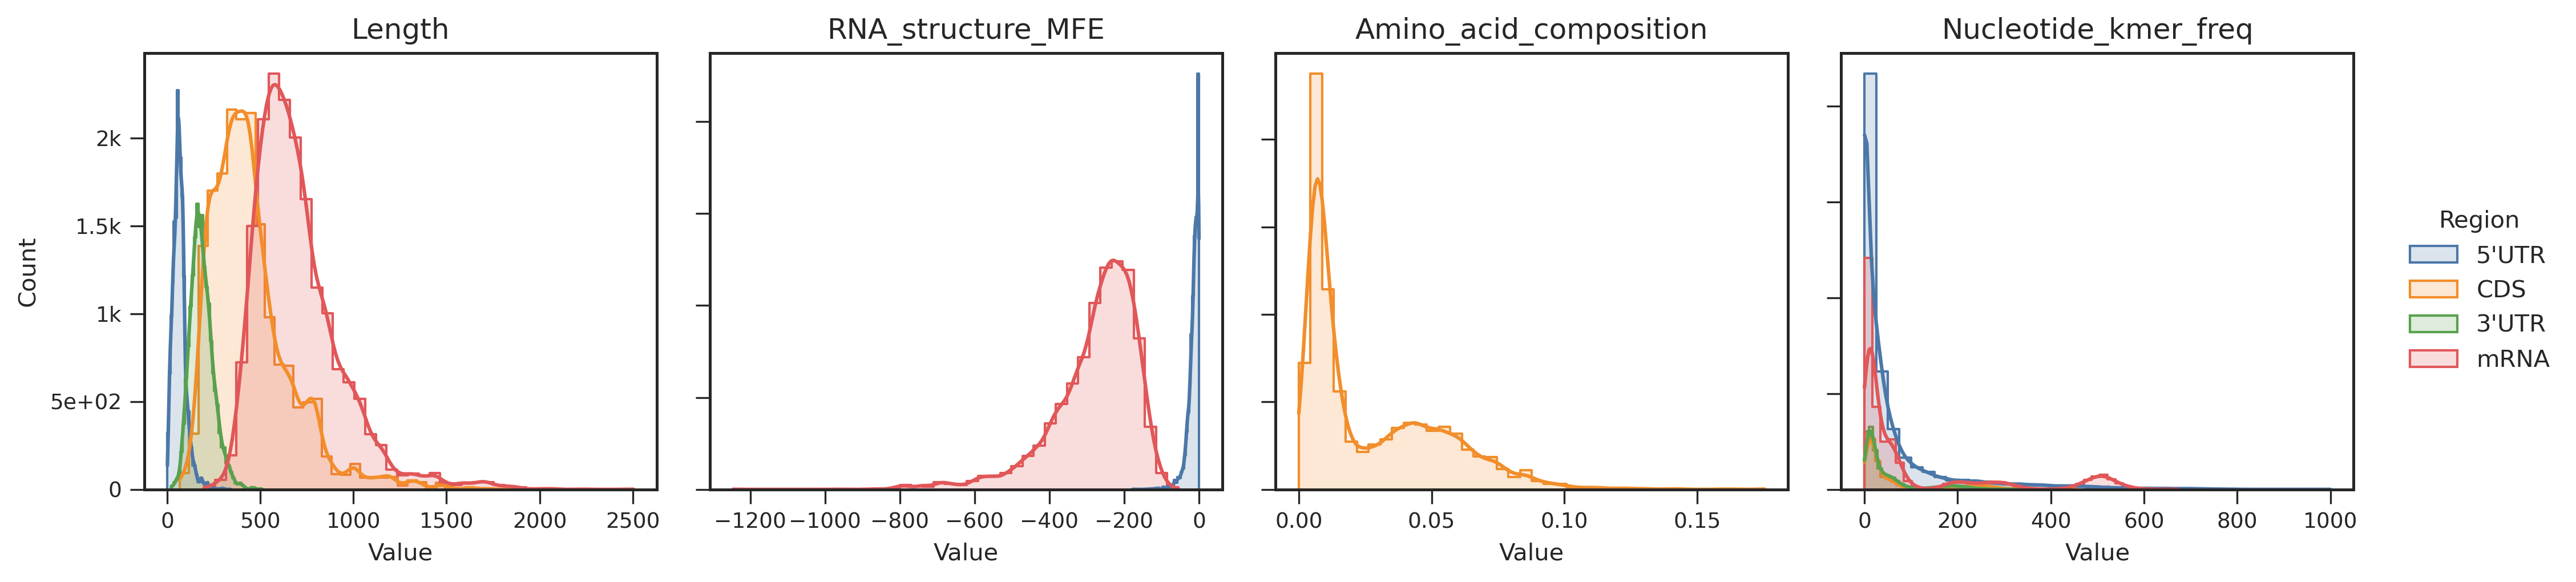

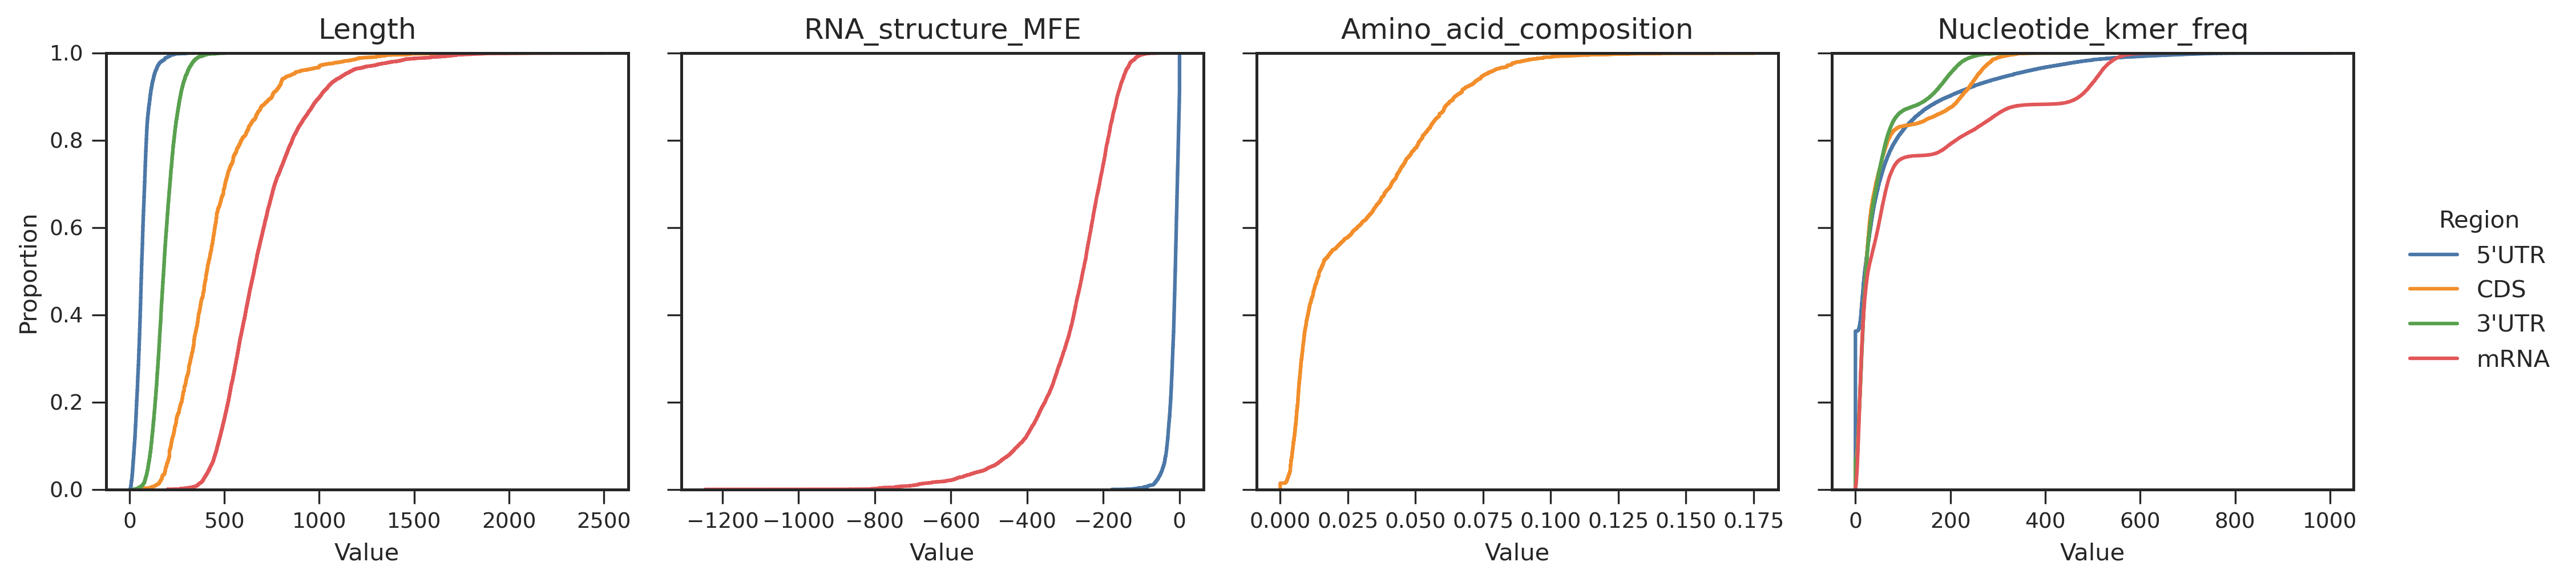

In [13]:
# ============================================
# Candidate feature distributions
# ============================================

feature_type_order = [
    "Length",
    "RNA_structure_MFE",
    "Amino_acid_composition",
    "Nucleotide_kmer_freq",
]

region_order = ["5'UTR", "CDS", "3'UTR", "mRNA"]

region_colors = {
    "5'UTR": "#4C78A8",
    "CDS": "#F28E2B",
    "3'UTR": "#59A14F",
    "mRNA": "#E15759",
}

plot_df = candidate_long_df.copy()
plot_df["Feature_type"] = pd.Categorical(plot_df["Feature_type"], categories=feature_type_order, ordered=True)
plot_df["Region"] = pd.Categorical(plot_df["Region"], categories=region_order, ordered=True)


# --------------------------------------------
# Histogram + KDE
# --------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), dpi=_PLOT_CFG["dpi"])

for ax, feature_type in zip(axes, feature_type_order):

    temp = plot_df[plot_df["Feature_type"] == feature_type]

    for region in region_order:

        values = temp.loc[temp["Region"] == region, "Value"].dropna()

        if len(values) == 0:
            continue

        sns.histplot(
            values,
            bins=40,
            stat="count",
            element="step",
            fill=True,
            alpha=0.20,
            kde=True,
            color=region_colors[region],
            label=region,
            ax=ax,
        )

    ax.set_title(feature_type)

    format_axis(
        ax,
        xlabel="Value",
        ylabel="Count" if ax is axes[0] else "",
        compact_ticks=("y",),
    )

    if ax is not axes[0]:
        ax.tick_params(labelleft=False)

handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Region",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.00, 0.5),
)

for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()


# --------------------------------------------
# ECDF
# --------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), dpi=_PLOT_CFG["dpi"])

for ax, feature_type in zip(axes, feature_type_order):

    temp = plot_df[plot_df["Feature_type"] == feature_type]

    for region in region_order:

        values = temp.loc[temp["Region"] == region, "Value"].dropna()

        if len(values) == 0:
            continue

        sns.ecdfplot(
            x=values,
            color=region_colors[region],
            linewidth=1.5,
            label=region,
            ax=ax,
        )

    ax.set_title(feature_type)

    format_axis(
        ax,
        xlabel="Value",
        ylabel="Proportion" if ax is axes[0] else "",
    )

    if ax is not axes[0]:
        ax.tick_params(labelleft=False)

handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Region",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.00, 0.5),
)

for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

In [15]:
# ============================================
# Candidate feature summary by species
# ============================================

summary_rows = []

for species in sorted(candidate_master_df["Species"].unique()):

    species_df = (
        candidate_master_df[
            candidate_master_df["Species"] == species
        ]
        .reset_index(drop=True)
    )

    for feature in candidate_features:

        meta = feature_metadata_df.loc[
            feature_metadata_df["Feature"] == feature
        ].iloc[0]

        values = species_df[feature]

        q25 = values.quantile(0.25)
        q75 = values.quantile(0.75)

        summary_rows.append({

            "Species": species,
            "Feature": feature,
            "Region": meta["Region"],
            "Feature_type": meta["Feature_type"],

            "n": values.notna().sum(),
            "missing_n": values.isna().sum(),
            "missing_pct": values.isna().mean() * 100,

            "zero_n": (values == 0).sum(),
            "zero_pct": (values == 0).mean() * 100,

            "mean": values.mean(),
            "std": values.std(),

            "median": values.median(),
            "q25": q25,
            "q75": q75,
            "IQR": q75 - q25,

            "min": values.min(),
            "max": values.max(),

            "skew": stats.skew(
                values,
                nan_policy="omit",
            ),

            "kurtosis": stats.kurtosis(
                values,
                nan_policy="omit",
            ),

            "variance": values.var(),

            "cv": (
                values.std() / values.mean()
                if values.mean() != 0
                else np.nan
            ),
        })

candidate_species_summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values(
        ["Species", "Region", "Feature_type", "Feature"]
    )
    .reset_index(drop=True)
)

print("Candidate feature summary by species")
print("------------------------------------")
print(candidate_species_summary_df.shape)

display(candidate_species_summary_df.head(20))

print("\nHighest skew")
display(
    candidate_species_summary_df
    .sort_values("skew", key=np.abs, ascending=False)
    .head(10)
)

print("\nHighest kurtosis")
display(
    candidate_species_summary_df
    .sort_values("kurtosis", key=np.abs, ascending=False)
    .head(10)
)

print("\nHighest zero percentage")
display(
    candidate_species_summary_df
    .sort_values("zero_pct", ascending=False)
    .head(10)
)

print("\nHighest coefficient of variation")
display(
    candidate_species_summary_df
    .sort_values("cv", ascending=False)
    .head(10)
)

Candidate feature summary by species
------------------------------------
(183, 21)


,Species,Feature,Region,Feature_type,n,missing_n,missing_pct,zero_n,zero_pct,mean,...,median,q25,q75,IQR,min,max,skew,kurtosis,variance,cv
0,AT,3'UTR.Length,3'UTR,Length,7126,0,0.0,0,0.000000,166.093040,...,162.000000,133.000000,196.000000,63.000000,22.00000,414.000000,0.620357,1.219593,2488.377167,0.300336
1,AT,3'UTR.ACA-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,1486,20.853214,11.284752,...,9.708738,4.830918,16.393443,11.562525,0.00000,68.965517,1.298475,2.488143,98.647880,0.880140
2,AT,3'UTR.AG-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,40,0.561325,43.455944,...,42.372881,31.421845,54.263566,22.841721,0.00000,148.148148,0.533762,1.058897,327.341091,0.416343
3,AT,3'UTR.AUC-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,417,5.851810,18.525699,...,17.094017,10.309278,25.196871,14.887593,0.00000,105.263158,0.841680,1.544945,128.749862,0.612490
4,AT,3'UTR.G-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,0,0.000000,172.249670,...,172.774869,150.326797,193.798450,43.471652,21.73913,363.636364,-0.021329,1.015588,1169.416764,0.198530
5,AT,3'UTR.GAU-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,448,6.286837,19.107572,...,18.072289,10.989011,25.613748,14.624737,0.00000,128.205128,1.073421,3.768234,137.992326,0.614783
6,AT,3'UTR.GUA-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,982,13.780522,14.127441,...,12.738854,6.666667,20.134228,13.467562,0.00000,57.971014,0.740365,0.561022,103.199136,0.719076
7,AT,3'UTR.UAG-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,1655,23.224811,9.115598,...,7.812500,4.255319,13.605442,9.350123,0.00000,59.701493,0.905447,1.340316,57.475163,0.831677
8,AT,3'UTR.UC-freq,3'UTR,Nucleotide_kmer_freq,7126,0,0.0,1,0.014033,71.026575,...,69.230769,55.214724,85.470085,30.255362,0.00000,204.081633,0.544044,1.183576,563.839285,0.334316
9,AT,5'UTR.Length,5'UTR,Length,7126,0,0.0,0,0.000000,58.505754,...,56.000000,36.000000,75.000000,39.000000,1.00000,301.000000,1.531708,5.144842,1116.368458,0.571091



Highest skew


,Species,Feature,Region,Feature_type,n,missing_n,missing_pct,zero_n,zero_pct,mean,...,median,q25,q75,IQR,min,max,skew,kurtosis,variance,cv
147,OS,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4681,84.311960,2.504039,...,0.0,0.0,0.000000,0.000000,0.0,93.023256,4.897579,34.031086,56.605838,3.004619
76,NB,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3694,68.648950,9.204376,...,0.0,0.0,13.333333,13.333333,0.0,250.000000,4.425113,29.319253,417.034144,2.218664
25,AT,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4859,68.186921,7.676439,...,0.0,0.0,12.987013,12.987013,0.0,200.000000,4.267204,34.854188,229.995845,1.975605
31,AT,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5708,80.101038,4.340798,...,0.0,0.0,0.000000,0.000000,0.0,166.666667,4.257893,28.504023,125.870158,2.584591
132,OS,5'UTR.ACA-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,2818,50.756484,14.642185,...,0.0,0.0,20.000000,20.000000,0.0,269.230769,3.548465,22.903271,585.323090,1.652312
30,AT,5'UTR.UGC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5082,71.316306,6.051929,...,0.0,0.0,10.680965,10.680965,0.0,133.333333,3.443196,19.527211,152.422847,2.040005
153,OS,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4205,75.738473,4.281709,...,0.0,0.0,0.000000,0.000000,0.0,100.000000,3.343287,15.488477,91.482640,2.233841
92,NB,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,4349,80.821409,3.853585,...,0.0,0.0,0.000000,0.000000,0.0,125.000000,3.244647,13.914384,91.364762,2.480415
12,AT,5'UTR.AGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4514,63.345495,9.556560,...,0.0,0.0,14.925373,14.925373,0.0,214.285714,3.234545,16.559598,307.298290,1.834334
15,AT,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5598,78.557395,4.715160,...,0.0,0.0,0.000000,0.000000,0.0,108.108108,3.199417,13.382437,123.064543,2.352719



Highest kurtosis


,Species,Feature,Region,Feature_type,n,missing_n,missing_pct,zero_n,zero_pct,mean,...,median,q25,q75,IQR,min,max,skew,kurtosis,variance,cv
25,AT,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4859,68.186921,7.676439,...,0.0,0.0,12.987013,12.987013,0.0,200.000000,4.267204,34.854188,229.995845,1.975605
147,OS,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4681,84.311960,2.504039,...,0.0,0.0,0.000000,0.000000,0.0,93.023256,4.897579,34.031086,56.605838,3.004619
76,NB,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3694,68.648950,9.204376,...,0.0,0.0,13.333333,13.333333,0.0,250.000000,4.425113,29.319253,417.034144,2.218664
31,AT,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5708,80.101038,4.340798,...,0.0,0.0,0.000000,0.000000,0.0,166.666667,4.257893,28.504023,125.870158,2.584591
132,OS,5'UTR.ACA-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,2818,50.756484,14.642185,...,0.0,0.0,20.000000,20.000000,0.0,269.230769,3.548465,22.903271,585.323090,1.652312
30,AT,5'UTR.UGC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5082,71.316306,6.051929,...,0.0,0.0,10.680965,10.680965,0.0,133.333333,3.443196,19.527211,152.422847,2.040005
73,NB,5'UTR.AGG-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3065,56.959673,11.265492,...,0.0,0.0,18.181818,18.181818,0.0,250.000000,3.049617,18.126434,330.442264,1.613606
12,AT,5'UTR.AGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4514,63.345495,9.556560,...,0.0,0.0,14.925373,14.925373,0.0,214.285714,3.234545,16.559598,307.298290,1.834334
153,OS,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4205,75.738473,4.281709,...,0.0,0.0,0.000000,0.000000,0.0,100.000000,3.343287,15.488477,91.482640,2.233841
133,OS,5'UTR.ACU-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,3148,56.700288,8.854476,...,0.0,0.0,14.492754,14.492754,0.0,130.434783,2.906196,14.392104,197.647165,1.587751



Highest zero percentage


,Species,Feature,Region,Feature_type,n,missing_n,missing_pct,zero_n,zero_pct,mean,...,median,q25,q75,IQR,min,max,skew,kurtosis,variance,cv
147,OS,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4681,84.311960,2.504039,...,0.0,0.0,0.000000,0.000000,0.0,93.023256,4.897579,34.031086,56.605838,3.004619
92,NB,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,4349,80.821409,3.853585,...,0.0,0.0,0.000000,0.000000,0.0,125.000000,3.244647,13.914384,91.364762,2.480415
31,AT,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5708,80.101038,4.340798,...,0.0,0.0,0.000000,0.000000,0.0,166.666667,4.257893,28.504023,125.870158,2.584591
15,AT,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5598,78.557395,4.715160,...,0.0,0.0,0.000000,0.000000,0.0,108.108108,3.199417,13.382437,123.064543,2.352719
153,OS,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4205,75.738473,4.281709,...,0.0,0.0,0.000000,0.000000,0.0,100.000000,3.343287,15.488477,91.482640,2.233841
77,NB,5'UTR.CCG-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3847,71.492288,6.600226,...,0.0,0.0,11.363636,11.363636,0.0,111.111111,2.660171,9.048071,170.440176,1.978004
30,AT,5'UTR.UGC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5082,71.316306,6.051929,...,0.0,0.0,10.680965,10.680965,0.0,133.333333,3.443196,19.527211,152.422847,2.040005
76,NB,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3694,68.648950,9.204376,...,0.0,0.0,13.333333,13.333333,0.0,250.000000,4.425113,29.319253,417.034144,2.218664
25,AT,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4859,68.186921,7.676439,...,0.0,0.0,12.987013,12.987013,0.0,200.000000,4.267204,34.854188,229.995845,1.975605
16,AT,5'UTR.CCG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4768,66.909907,7.747402,...,0.0,0.0,13.157895,13.157895,0.0,142.857143,2.474153,8.496293,194.735318,1.801218



Highest coefficient of variation


,Species,Feature,Region,Feature_type,n,missing_n,missing_pct,zero_n,zero_pct,mean,...,median,q25,q75,IQR,min,max,skew,kurtosis,variance,cv
147,OS,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4681,84.311960,2.504039,...,0.0,0.0,0.000000,0.000000,0.0,93.023256,4.897579,34.031086,56.605838,3.004619
31,AT,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5708,80.101038,4.340798,...,0.0,0.0,0.000000,0.000000,0.0,166.666667,4.257893,28.504023,125.870158,2.584591
92,NB,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,4349,80.821409,3.853585,...,0.0,0.0,0.000000,0.000000,0.0,125.000000,3.244647,13.914384,91.364762,2.480415
15,AT,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5598,78.557395,4.715160,...,0.0,0.0,0.000000,0.000000,0.0,108.108108,3.199417,13.382437,123.064543,2.352719
153,OS,5'UTR.UGG-freq,5'UTR,Nucleotide_kmer_freq,5552,0,0.0,4205,75.738473,4.281709,...,0.0,0.0,0.000000,0.000000,0.0,100.000000,3.343287,15.488477,91.482640,2.233841
76,NB,5'UTR.CCC-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3694,68.648950,9.204376,...,0.0,0.0,13.333333,13.333333,0.0,250.000000,4.425113,29.319253,417.034144,2.218664
30,AT,5'UTR.UGC-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,5082,71.316306,6.051929,...,0.0,0.0,10.680965,10.680965,0.0,133.333333,3.443196,19.527211,152.422847,2.040005
77,NB,5'UTR.CCG-freq,5'UTR,Nucleotide_kmer_freq,5381,0,0.0,3847,71.492288,6.600226,...,0.0,0.0,11.363636,11.363636,0.0,111.111111,2.660171,9.048071,170.440176,1.978004
25,AT,5'UTR.UAU-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4859,68.186921,7.676439,...,0.0,0.0,12.987013,12.987013,0.0,200.000000,4.267204,34.854188,229.995845,1.975605
12,AT,5'UTR.AGG-freq,5'UTR,Nucleotide_kmer_freq,7126,0,0.0,4514,63.345495,9.556560,...,0.0,0.0,14.925373,14.925373,0.0,214.285714,3.234545,16.559598,307.298290,1.834334
